In [36]:
%matplotlib inline
# Python packages
import numpy as np
import pandas as pd
#import seaborn as sbn
import matplotlib.pyplot as plt
import math
import scipy.optimize as optimization
import scipy.integrate
from astropy.cosmology import LambdaCDM
import hmf

In [40]:
import astropy

In [37]:
# MICE Cosmology
omega_radiation = 0. # Omega radiation at z=0
omega_DM = 0.21 # Omega DM at z=0
omega_barion = 0.04 # Omega barion at z=0
omega_curvature = 0. # Omega curvature at z=0
omega_lambda = 0.75 # Omega Lambda at z=0
h = 0.7 # Ignorance paramter
# MICE simulation
lbox = 3072.
volume =  math.pow(lbox,3)# simulation volume

In [38]:
log_halo_mass_file = '/Users/jcarrete/sandbox/micecatv1.0_halomass.ssv.bz2'
log_halo_mass_sample_file = '/Users/jcarrete/sandbox/micecatv1.0_halomass_sample.ssv'

In [39]:
# Mass Function bins
# mass bins
log_mass_bins_edges = np.linspace(9.0, 16.0, num=71)
print ('log_mass_bins_edges')
print (log_mass_bins_edges)
log_mean_mass_bins = (log_mass_bins_edges[0:-1] + log_mass_bins_edges[1:])/2
print ('log_mean_mass_bins')
print (log_mean_mass_bins)
print ('number of bins =',len(log_mean_mass_bins))
delta_log_mass = (log_mass_bins_edges[1]- log_mass_bins_edges[0])
print ('delta_log_mass =',delta_log_mass)

log_mass_bins_edges
[ 9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7  9.8  9.9 10.  10.1 10.2 10.3
 10.4 10.5 10.6 10.7 10.8 10.9 11.  11.1 11.2 11.3 11.4 11.5 11.6 11.7
 11.8 11.9 12.  12.1 12.2 12.3 12.4 12.5 12.6 12.7 12.8 12.9 13.  13.1
 13.2 13.3 13.4 13.5 13.6 13.7 13.8 13.9 14.  14.1 14.2 14.3 14.4 14.5
 14.6 14.7 14.8 14.9 15.  15.1 15.2 15.3 15.4 15.5 15.6 15.7 15.8 15.9
 16. ]
log_mean_mass_bins
[ 9.05  9.15  9.25  9.35  9.45  9.55  9.65  9.75  9.85  9.95 10.05 10.15
 10.25 10.35 10.45 10.55 10.65 10.75 10.85 10.95 11.05 11.15 11.25 11.35
 11.45 11.55 11.65 11.75 11.85 11.95 12.05 12.15 12.25 12.35 12.45 12.55
 12.65 12.75 12.85 12.95 13.05 13.15 13.25 13.35 13.45 13.55 13.65 13.75
 13.85 13.95 14.05 14.15 14.25 14.35 14.45 14.55 14.65 14.75 14.85 14.95
 15.05 15.15 15.25 15.35 15.45 15.55 15.65 15.75 15.85 15.95]
number of bins = 70
delta_log_mass = 0.09999999999999964


In [5]:
gal_chunk = 10000000
counts_log_mass = np.zeros(len(log_mean_mass_bins))
galaxy_sample_reader = pd.read_csv(
    log_halo_mass_file,
    chunksize=gal_chunk,
    compression='bz2'
)
for chunk, block in enumerate(galaxy_sample_reader):
    print(chunk)
    counts_block_log_mass = np.histogram(block, bins=log_mass_bins_edges)
    counts_log_mass = counts_log_mass + counts_block_log_mass[0]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15


In [43]:
# Selecting the points that I use to fit the Schechter function
relevant_counts_log_mass = counts_log_mass[counts_log_mass>0]
relevant_log_mean_mass = log_mean_mass_bins[counts_log_mass>0]
#print counts_log_mass
#print relevant_counts_log_mass
# Error as a Poisson distribution
relevant_counts_log_mass_error = np.sqrt(relevant_counts_log_mass)
#print log_mean_mass_bins
#print relevant_log_mean_mass

In [7]:
# Mass Function
dn_dlogm = relevant_counts_log_mass/(delta_log_mass*volume)
dn_dlogm_error = np.sqrt(relevant_counts_log_mass_error)/(delta_log_mass*volume)
log_dn_dlogm = np.log10(dn_dlogm)
log_dn_dlogm_error = np.sqrt(relevant_counts_log_mass_error)/relevant_counts_log_mass_error

print(dn_dlogm)
print(dn_dlogm_error)
print(log_dn_dlogm)
print(log_dn_dlogm_error)

[8.77484852e-03 8.47595640e-03 6.82754511e-03 5.61383587e-03
 4.64376097e-03 3.87479103e-03 3.21491828e-03 2.64192345e-03
 2.15389179e-03 1.74340861e-03 1.39659754e-03 1.11143036e-03
 8.76845378e-04 6.86816595e-04 5.33693367e-04 4.12251317e-04
 3.15839425e-04 2.41638886e-04 1.79092641e-04 1.34944847e-04
 1.00022665e-04 7.29908546e-05 5.28618693e-05 3.65975278e-05
 2.57565881e-05 1.75392186e-05 1.17329398e-05 7.71514519e-06
 4.71766624e-06 2.96988421e-06 1.76985783e-06 1.02548963e-06
 5.56723939e-07 2.93539078e-07 1.42802795e-07 7.65754117e-08
 3.00092830e-08 1.55220429e-08 3.44934287e-09 2.06960572e-09
 3.44934287e-10]
[2.44969593e-08 2.42856344e-08 2.30074464e-08 2.19087300e-08
 2.08939109e-08 1.99693692e-08 1.90587652e-08 1.81460596e-08
 1.72428180e-08 1.63550573e-08 1.54728421e-08 1.46141257e-08
 1.37731421e-08 1.29572390e-08 1.21653673e-08 1.14049343e-08
 1.06701091e-08 9.97915988e-09 9.25916258e-09 8.62663356e-09
 8.00436491e-09 7.39808619e-09 6.82476817e-09 6.22537062e-09
 5.7019

Text(0.5, 1.0, 'Halo mass function')

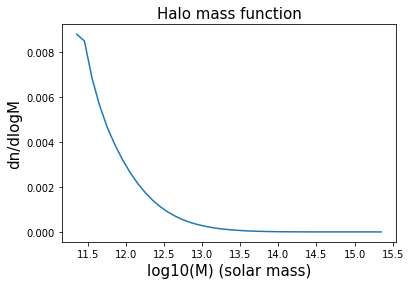

In [8]:
# Figure
# Halo mass function
fig, ax = plt.subplots()
dn_dlogm_plot = ax.errorbar(relevant_log_mean_mass, dn_dlogm, yerr = dn_dlogm_error)
ax.set_ylabel('dn/dlogM',fontsize=15)
ax.set_xlabel('log10(M) (solar mass)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

Text(0.5, 1.0, 'Halo mass function')

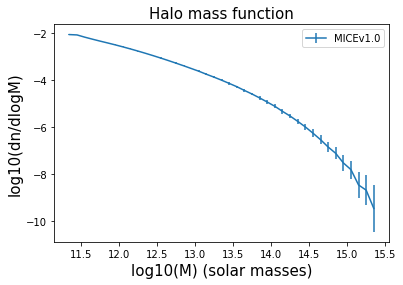

In [9]:
# Plot log(Mass Function)
fig, ax = plt.subplots()
log_dn_dlogm_plot = ax.errorbar(relevant_log_mean_mass, log_dn_dlogm, yerr = log_dn_dlogm_error, label = 'MICEv1.0')
ax.legend()
ax.set_ylabel('log10(dn/dlogM)',fontsize=15)
ax.set_xlabel('log10(M) (solar masses)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

In [10]:
# Schechter function with 4 parameters to fit log10(dn/dlogM)
def schechter4p(log_mass, a, b, c, d):
    # log_mass: input data given in log10
    # output is in log10
    # a normalization given in log10
    # c mstar given in log10

    t = np.power(10.,log_mass)/np.power(10.,c)
    return np.log10(np.power(10., a)*np.power(t, b)*np.exp(-pow((t), d)))

Text(0.5, 1.0, 'Halo mass function')

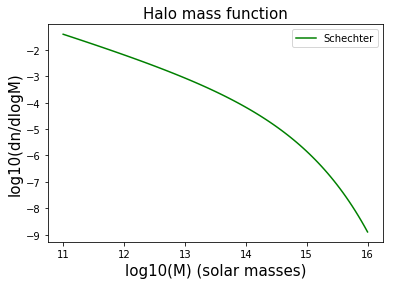

In [11]:
# Plotting model with initial guess values
logm = np.linspace(11., 16.0, num=100)
schechter_y = schechter4p(logm,-3.185856, -0.717987, 13.539835, 0.389420)
fig, ax = plt.subplots()
figura = ax.plot(logm, schechter_y,label = 'Schechter', color = 'g')
ax.legend()
ax.set_ylabel('log10(dn/dlogM)',fontsize=15)
ax.set_xlabel('log10(M) (solar masses)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

In [12]:
# Analitical fit
# Initial guess
x0 = np.array([-3.185856, -0.717987, 13.539835, 0.389420])
# Best parameters No errors
xfinal_noerr = optimization.curve_fit(schechter4p, relevant_log_mean_mass, log_dn_dlogm, x0)
print(xfinal_noerr)

xfinal_err = optimization.curve_fit(schechter4p, relevant_log_mean_mass, log_dn_dlogm, x0,sigma=log_dn_dlogm_error, absolute_sigma=False)
print(xfinal_err)

log_dn_dlogm_fit_noerr = schechter4p(logm,xfinal_noerr[0][0],xfinal_noerr[0][1],xfinal_noerr[0][2],xfinal_noerr[0][3])
log_dn_dlogm_fit_err = schechter4p(logm,xfinal_err[0][0],xfinal_err[0][1],xfinal_err[0][2],xfinal_err[0][3])

(array([-3.38091644, -0.78147207, 13.21198033,  0.46507779]), array([[ 0.0235345 ,  0.00517062, -0.01789432, -0.00303462],
       [ 0.00517062,  0.00121849, -0.0039169 , -0.00065051],
       [-0.01789432, -0.0039169 ,  0.01365189,  0.00232383],
       [-0.00303462, -0.00065051,  0.00232383,  0.00040002]]))
(array([-2.12841978, -0.5475695 , 12.02620108,  0.31767233]), array([[ 0.06274166,  0.01135175, -0.07191198, -0.00594471],
       [ 0.01135175,  0.00210197, -0.01300669, -0.00106168],
       [-0.07191198, -0.01300669,  0.08243243,  0.0068171 ],
       [-0.00594471, -0.00106168,  0.0068171 ,  0.00056944]]))


Text(0.5, 1.0, 'Halo mass function')

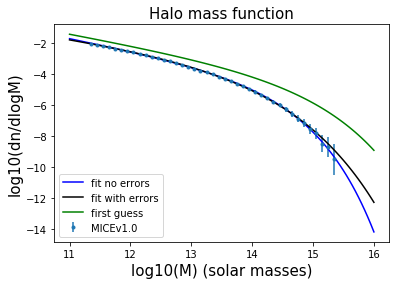

In [13]:
# Plot log(Mass Function)
fig, ax = plt.subplots()
log_dn_dlogm_plot = ax.errorbar(relevant_log_mean_mass, log_dn_dlogm, yerr = log_dn_dlogm_error,fmt='o',markersize=3, label='MICEv1.0')
fit_noerror_plot = ax.plot(logm, log_dn_dlogm_fit_noerr,'b', label='fit no errors')
fit_error_plot = ax.plot(logm, log_dn_dlogm_fit_err,'k', label='fit with errors')
fit_initial_guess = ax.plot(logm, schechter_y,'g', label = 'first guess')
ax.legend(loc=3)
ax.set_ylabel('log10(dn/dlogM)',fontsize=15)
ax.set_xlabel('log10(M) (solar masses)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

Text(0.5, 0, 'log10(M) (solar masses)')

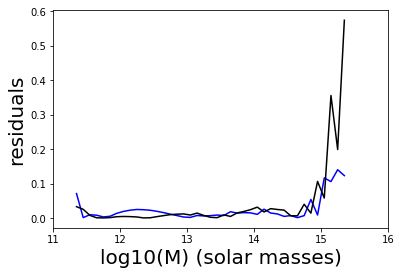

In [14]:
#Residuals
log_dn_dlogm_fit_noerr = schechter4p(relevant_log_mean_mass,xfinal_noerr[0][0],xfinal_noerr[0][1],xfinal_noerr[0][2],xfinal_noerr[0][3])
log_dn_dlogm_fit_err = schechter4p(relevant_log_mean_mass,xfinal_err[0][0],xfinal_err[0][1],xfinal_err[0][2],xfinal_err[0][3])
residual_noerr = abs(log_dn_dlogm_fit_noerr-log_dn_dlogm)
residual_err = abs(log_dn_dlogm_fit_err-log_dn_dlogm) 
fig, ax = plt.subplots() 
residual_noerr_plot = ax.plot(relevant_log_mean_mass, residual_noerr, 'b') 
residual_err_plot = ax.plot(relevant_log_mean_mass, residual_err, 'k') 
ax.set_ylabel('residuals',fontsize=20)
ax.set_xlim(11.0,16.0)
ax.set_xlabel('log10(M) (solar masses)',fontsize=20)

In [15]:
# Hasta aquí!

In [16]:
# Using the correct library
# Only one redshift shell

In [17]:
# MICECATv1.0 logm file from CosmoHub
# SELECT `log_m`, `id` FROM micecatv1_0_hpix WHERE `flag` = 0 AND `z` > 0.9 AND `z` < 1.1
log_halo_mass_file_z_0_1 = '/nfs/astro/jcarrete/sandbox/curso_python/2460.csv'
log_halo_mass_file_z_0_1 = '/Users/jcarrete/Dropbox/Cosmology/TEACHING/Curso_Master_Galaxies_and_Extragalactic_Astrophysics/2460.csv.bz2'

In [42]:
# Why is it necessary to initialize the cosmology with the temperature for the dndm??
#cosmology = LambdaCDM(H0=100, Om0=0.25, Ode0=1-0.25, Ob0=0.044)
#print(cosmology)
cosmology = LambdaCDM(H0=100, Om0=0.25, Ode0=1-0.25, Ob0=0.044, Tcmb0=2.725)
print(cosmology)
(r1, r2) = cosmology.comoving_distance([0.9,1.4545])
print(r1, r2)

LambdaCDM(H0=100 km / (Mpc s), Om0=0.25, Ode0=0.75, Tcmb0=2.725 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=0.044)
2199.7400656924406 Mpc 3114.7976476038043 Mpc


In [19]:
volume =  (1./8.)*(4./3.)*math.pi*(math.pow(r2.value,3)-math.pow(r1.value,3))# simulation volume
print(volume)

3226464173.67645


In [20]:
gal_chunk = 10000000
counts_log_mass = np.zeros(len(log_mean_mass_bins))
galaxy_sample_bz2_reader = pd.read_csv(
    log_halo_mass_file_z_0_1, 
    sep=',', 
    index_col = 'id', 
    comment='#', 
    na_values = '\\N',
    chunksize=gal_chunk,
    compression='bz2'
)
for chunk, block in enumerate(galaxy_sample_bz2_reader):
    print(chunk)
    counts_block_log_mass = np.histogram(block, bins=log_mass_bins_edges)
    counts_log_mass = counts_log_mass + counts_block_log_mass[0]

/Users/jcarrete/sandbox/ENV/python3_bootcamp/lib/python3.5/site-packages/numpy/lib/arraysetops.py:522: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


0
1
2
3


In [21]:
# Selecting the points that I use to fit the Schechter function
relevant_counts_log_mass = counts_log_mass[counts_log_mass>0]
relevant_log_mean_mass = log_mean_mass_bins[counts_log_mass>0]
#print counts_log_mass
#print relevant_counts_log_mass
# Error as a Poisson distribution
relevant_counts_log_mass_error = np.sqrt(relevant_counts_log_mass)
#print log_mean_mass_bins
#print relevant_log_mean_mass

In [22]:
relevant_log_mean_mass

array([11.35, 11.45, 11.55, 11.65, 11.75, 11.85, 11.95, 12.05, 12.15,
       12.25, 12.35, 12.45, 12.55, 12.65, 12.75, 12.85, 12.95, 13.05,
       13.15, 13.25, 13.35, 13.45, 13.55, 13.65, 13.75, 13.85, 13.95,
       14.05, 14.15, 14.25, 14.35, 14.45, 14.55, 14.65, 14.75, 14.85,
       14.95])

In [23]:
# Mass Function
dn_dlogm = relevant_counts_log_mass/(delta_log_mass*volume)
dn_dlogm_error = np.sqrt(relevant_counts_log_mass_error)/(delta_log_mass*volume)
log_dn_dlogm = np.log10(dn_dlogm)
log_dn_dlogm_error = np.sqrt(relevant_counts_log_mass_error)/relevant_counts_log_mass_error

print(dn_dlogm)
print(dn_dlogm_error)
print(log_dn_dlogm)
print(log_dn_dlogm_error)

[1.69782638e-02 1.64009848e-02 1.32357056e-02 1.08891803e-02
 9.01391692e-03 7.52571815e-03 6.25039638e-03 5.14321843e-03
 4.18460868e-03 3.39250319e-03 2.70936528e-03 2.15426846e-03
 1.69658168e-03 1.32997913e-03 1.02766367e-03 7.91150889e-04
 6.03217608e-04 4.59692072e-04 3.38729935e-04 2.52620192e-04
 1.85819513e-04 1.33517677e-04 9.54295425e-05 6.52107039e-05
 4.45038259e-05 2.91588547e-05 1.86519970e-05 1.15203511e-05
 6.88989519e-06 3.84011702e-06 2.16955764e-06 1.00109588e-06
 4.46309000e-07 1.95260188e-07 9.60804098e-08 3.40930486e-08
 6.19873612e-09]
[1.49943687e-07 1.48652544e-07 1.40893721e-07 1.34184905e-07
 1.27992126e-07 1.22346585e-07 1.16797018e-07 1.11240673e-07
 1.05649775e-07 1.00250127e-07 9.47701908e-08 8.94910946e-08
 8.43040731e-08 7.93260941e-08 7.43733965e-08 6.96658106e-08
 6.50988576e-08 6.08235295e-08 5.63531581e-08 5.23687105e-08
 4.84984316e-08 4.46518602e-08 4.10558998e-08 3.73279884e-08
 3.39276830e-08 3.05244242e-08 2.72983375e-08 2.42003303e-08
 2.1281

Text(0.5, 1.0, 'Halo mass function')

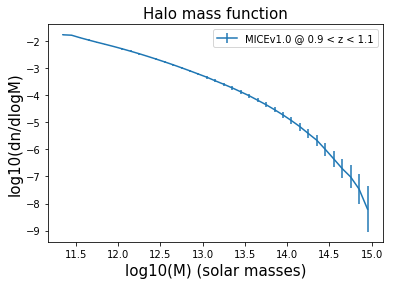

In [24]:
# Plot log(Mass Function)
fig, ax = plt.subplots()
log_dn_dlogm_plot = ax.errorbar(relevant_log_mean_mass, log_dn_dlogm, yerr = log_dn_dlogm_error, label = 'MICEv1.0 @ 0.9 < z < 1.1')
ax.legend()
ax.set_ylabel('log10(dn/dlogM)',fontsize=15)
ax.set_xlabel('log10(M) (solar masses)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

In [44]:
h_0_9 = hmf.hmf.MassFunction(Mmin=11.35, Mmax=15.00, dlog10m=0.1, z=0.9, hmf_model="Tinker10")
h_1_0 = hmf.hmf.MassFunction(Mmin=11.35, Mmax=15.00, dlog10m=0.1, z=1.0, hmf_model="Tinker10")
h_1_1 = hmf.hmf.MassFunction(Mmin=11.35, Mmax=15.00, dlog10m=0.1, z=1.1, hmf_model="Tinker10")

In [45]:
h_1_0.cosmo_model

FlatLambdaCDM(name="Planck15", H0=67.7 km / (Mpc s), Om0=0.307, Tcmb0=2.725 K, Neff=3.05, m_nu=[0.   0.   0.06] eV, Ob0=0.0486)

In [46]:
h_0_9.update(cosmo_model=cosmology)
h_1_0.update(cosmo_model=cosmology)
h_1_1.update(cosmo_model=cosmology)

In [47]:
h_1_0.cosmo_model

LambdaCDM(H0=100 km / (Mpc s), Om0=0.25, Ode0=0.75, Tcmb0=2.725 K, Neff=3.04, m_nu=[0. 0. 0.] eV, Ob0=0.044)

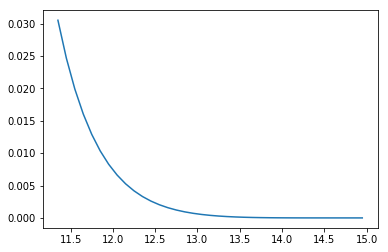

In [48]:
plt.plot(np.log10(h_1_0.m),h_1_0.dndlog10m)
#plt.yscale('log')

Text(0.5, 1.0, 'Halo mass function')

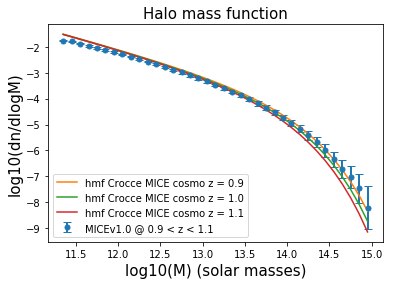

In [49]:
# Plot log(Mass Function)
fig, ax = plt.subplots()
log_dn_dlogm_plot = ax.errorbar(relevant_log_mean_mass, log_dn_dlogm, yerr = log_dn_dlogm_error, fmt='.', markersize='10' ,capsize=4, elinewidth=2, label = 'MICEv1.0 @ 0.9 < z < 1.1')
ax.plot(np.log10(h_0_9.m),np.log10(h_0_9.dndlog10m), label = 'hmf Crocce MICE cosmo z = 0.9')
ax.plot(np.log10(h_1_0.m),np.log10(h_1_0.dndlog10m), label = 'hmf Crocce MICE cosmo z = 1.0')
ax.plot(np.log10(h_1_1.m),np.log10(h_1_1.dndlog10m), label = 'hmf Crocce MICE cosmo z = 1.1')
ax.legend(loc='best')
ax.set_ylabel('log10(dn/dlogM)',fontsize=15)
ax.set_xlabel('log10(M) (solar masses)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

Text(0.5, 1.0, 'Halo mass function')

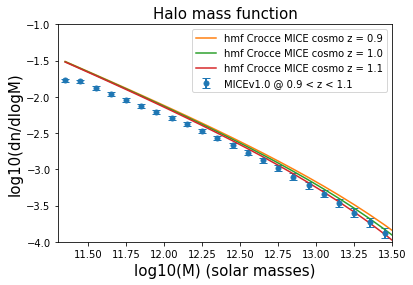

In [50]:
# Plot log(Mass Function)
fig, ax = plt.subplots()
log_dn_dlogm_plot = ax.errorbar(relevant_log_mean_mass, log_dn_dlogm, yerr = log_dn_dlogm_error, fmt='.', markersize='10' ,capsize=4, elinewidth=2, label = 'MICEv1.0 @ 0.9 < z < 1.1')
ax.plot(np.log10(h_0_9.m),np.log10(h_0_9.dndlog10m), label = 'hmf Crocce MICE cosmo z = 0.9')
ax.plot(np.log10(h_1_0.m),np.log10(h_1_0.dndlog10m), label = 'hmf Crocce MICE cosmo z = 1.0')
ax.plot(np.log10(h_1_1.m),np.log10(h_1_1.dndlog10m), label = 'hmf Crocce MICE cosmo z = 1.1')
ax.legend(loc='best')
ax.set_xlim([11.3,13.5])
ax.set_ylim([-4.,-1.])
ax.set_ylabel('log10(dn/dlogM)',fontsize=15)
ax.set_xlabel('log10(M) (solar masses)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

Text(0.5, 1.0, 'Halo mass function')

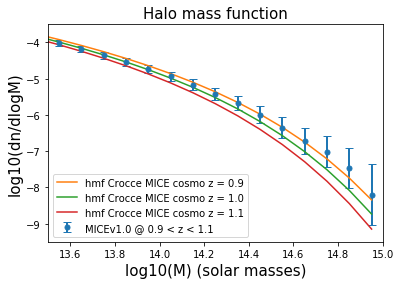

In [51]:
# Plot log(Mass Function)
fig, ax = plt.subplots()
log_dn_dlogm_plot = ax.errorbar(relevant_log_mean_mass, log_dn_dlogm, yerr = log_dn_dlogm_error, fmt='.', markersize='10' ,capsize=4, elinewidth=2, label = 'MICEv1.0 @ 0.9 < z < 1.1')
ax.plot(np.log10(h_0_9.m),np.log10(h_0_9.dndlog10m), label = 'hmf Crocce MICE cosmo z = 0.9')
ax.plot(np.log10(h_1_0.m),np.log10(h_1_0.dndlog10m), label = 'hmf Crocce MICE cosmo z = 1.0')
ax.plot(np.log10(h_1_1.m),np.log10(h_1_1.dndlog10m), label = 'hmf Crocce MICE cosmo z = 1.1')
ax.legend(loc='best')
ax.set_xlim([13.5,15.0])
ax.set_ylim([-9.5,-3.5])
ax.set_ylabel('log10(dn/dlogM)',fontsize=15)
ax.set_xlabel('log10(M) (solar masses)',fontsize=15)
ax.set_title('Halo mass function',fontsize=15)

Text(0.5, 0, 'log10(M) (solar masses)')

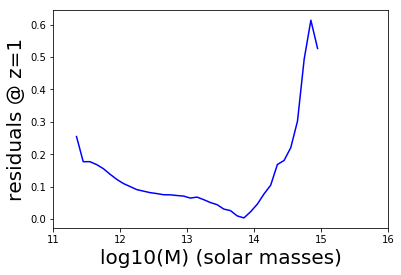

In [52]:
#Residuals
residual = np.abs(log_dn_dlogm - np.log10(h_1_0.dndlog10m))
fig, ax = plt.subplots() 
residual_plot = ax.plot(relevant_log_mean_mass, residual, 'b') 
ax.set_ylabel('residuals @ z=1',fontsize=20)
ax.set_xlim(11.0,16.0)
ax.set_xlabel('log10(M) (solar masses)',fontsize=20)

In [34]:
import matplotlib.pyplot as plt
from ipywidgets import interact

def f(n):
    plt.plot([0,1,2],[0,1,n])
    plt.show()
interact(f,n=(0,10))

interactive(children=(IntSlider(value=5, description='n', max=10), Output()), _dom_classes=('widget-interact',…

<function __main__.f(n)>

In [ ]:
dir(h_0_9)

In [21]:
# Example
# Generate artificial data = straight line with a=0 and b=1
# plus some noise.
xdata = np.array([0.0,1.0,2.0,3.0,4.0,5.0])
ydata = np.array([0.1,0.9,2.2,2.8,3.9,5.1])
# Initial guess.
x0 = np.array([0.0, 0.0, 0.0])
#With errors!
sigma = np.array([1.0,1.0,1.0,1.0,1.0,1.0])
# Function to fit
def func(x, a, b, c):
    return a + b*x + c*x*x
print optimization.curve_fit(func, xdata, ydata, x0, sigma)

(array([ 0.1       ,  0.88142857,  0.02142857]), array([[ 0.02753741, -0.0197551 ,  0.0029932 ],
       [-0.0197551 ,  0.02436463, -0.0044898 ],
       [ 0.0029932 , -0.0044898 ,  0.00089796]]))


In [22]:
# Creo una funcion donde dado logM te devuelve el dn_dlogm
def dMFfit(logM):
    x = np.zeros(4,)
    x[0] = -3.38091646
    x[1] = -0.78147207
    x[2] = 13.21198034
    x[3] = 0.46507779
    return np.power(10.,schechter4p(logM, x[0], x[1], x[2], x[3]))
ans = dMFfit(12.0)
print np.log10(ans)

-2.55239709245


In [23]:
ans = scipy.integrate.romberg(dMFfit,12.,16.)
print np.log10(ans)

-2.91206454718


In [24]:
# Cumulative Mass Function
# Returns the cumulative mass function given logm
def cMFfit(logM_min):
    logM_max = 16.
    return (scipy.integrate.romberg(dMFfit, logM_min, logM_max))
cMfit_vect= np.vectorize(cMFfit)
#print xfinal[0]
cMfit_tab = cMfit_vect(logm)
#print cMfit_tab

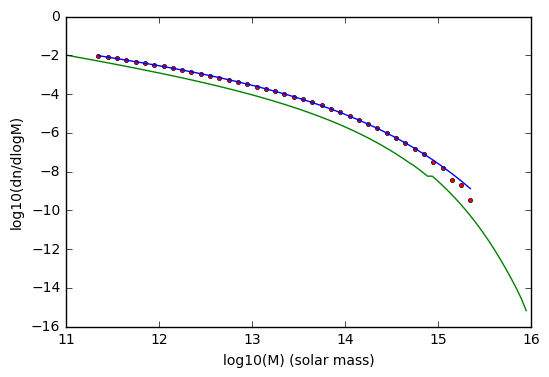

In [25]:
# Plotting Cumulative mass function
plt.plot(relevant_log_mean_mass, log_dn_dlogm,'ro',markersize=3)
plt.plot(relevant_log_mean_mass, log_dn_dlogm_fit_err,'b')
plt.plot(logm, np.log10(cMfit_tab), 'g')
plt.xlabel('log10(M) (solar mass)')
plt.ylabel('log10(dn/dlogM)')